# Student Performance Prediction using Linear Regression (Gradient Descent)

## Step 1: Import Required Libraries

In this step, we import all the necessary Python libraries required for data preprocessing,
visualization, numerical computations, and model evaluation.

The Student Performance dataset (student-mat.csv) is then loaded into a Pandas DataFrame.
Finally, the first few records, dataset dimensions, and basic information are displayed to
understand the structure of the dataset.

In [2]:
# Import required libraries

import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from the provided archive
work_dir = Path(r"d:\MCA\SEM-4\Machine Learning\Lab-5")
archive_path = work_dir / "student+performance.zip"
extract_dir = work_dir / "dataset_extracted"
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(archive_path, "r") as outer_zip:
    outer_zip.extractall(extract_dir)

inner_zip_path = extract_dir / "student.zip"
with zipfile.ZipFile(inner_zip_path, "r") as inner_zip:
    inner_zip.extractall(extract_dir)

csv_path = extract_dir / "student-mat.csv"
df = pd.read_csv(csv_path, sep=";")

print("First 5 rows:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nDataset info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Dataset shape: (395, 33)

Dataset info:
<class 'pandas.core.frame.DataFra

## Step 2: Clean and preprocess the data

In this step, we inspect missing values, fill any missing numeric or categorical values if needed,
and encode all categorical columns using one-hot encoding.

In [3]:
df_processed = df.copy()

numeric_cols = df_processed.select_dtypes(include=np.number).columns
categorical_cols = df_processed.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in categorical_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

print("Remaining missing values:", df_processed.isnull().sum().sum())

df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
print("Encoded dataset shape:", df_encoded.shape)

Remaining missing values: 0
Encoded dataset shape: (395, 42)


## Step 3: Select input features and the target variable

We predict the final grade, `G3`, using the remaining columns as input features.

In [4]:
target_column = "G3"
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

print("Input features shape:", X.shape)
print("Target shape:", y.shape)
print("Sample feature columns:", list(X.columns[:10]))

Input features shape: (395, 41)
Target shape: (395,)
Sample feature columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc']


## Step 4: Split the data and scale the features

We split the dataset into training and testing sets, then standardize the input features
so gradient descent converges more smoothly.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (316, 41)
Testing set shape: (79, 41)


## Step 5: Implement linear regression with gradient descent

This custom model uses batch gradient descent to minimize mean squared error and stores the
loss after every iteration so we can inspect convergence.

In [11]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## Step 6: Train the model with different learning rates

We train the model with multiple learning rates to compare convergence speed and stability,
then plot the loss curves against iteration number.

Learning rate: 0.001 | Final training loss: 5.2583
Learning rate: 0.01 | Final training loss: 2.8266
Learning rate: 0.05 | Final training loss: 2.8231
Learning rate: 0.1 | Final training loss: 2.8231

Best learning rate based on final training loss: 0.1


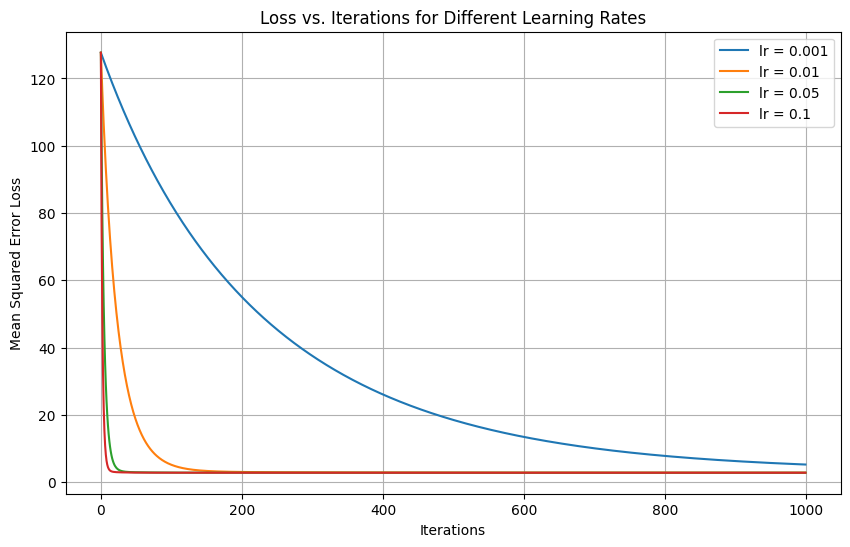

In [7]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
n_iters = 1000

models = {}
loss_histories = {}
final_losses = {}

for lr in learning_rates:
    model = LinearRegressionGD(learning_rate=lr, n_iters=n_iters)
    model.fit(X_train_scaled, y_train_array)
    models[lr] = model
    loss_histories[lr] = model.loss_history
    final_losses[lr] = model.loss_history[-1]
    print(f"Learning rate: {lr} | Final training loss: {model.loss_history[-1]:.4f}")

best_learning_rate = min(final_losses, key=final_losses.get)
best_model = models[best_learning_rate]

print("\nBest learning rate based on final training loss:", best_learning_rate)

plt.figure(figsize=(10, 6))
for lr, history in loss_histories.items():
    plt.plot(history, label=f"lr = {lr}")

plt.title("Loss vs. Iterations for Different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Evaluate the trained model

We use the best learning-rate model to predict test data and compute MAE, MSE, RMSE, and R²
for a clear measure of prediction performance.

Evaluation Metrics
------------------
Mean Absolute Error (MAE): 1.6467
Mean Squared Error (MSE): 5.6566
Root Mean Squared Error (RMSE): 2.3784
R² Score: 0.7241


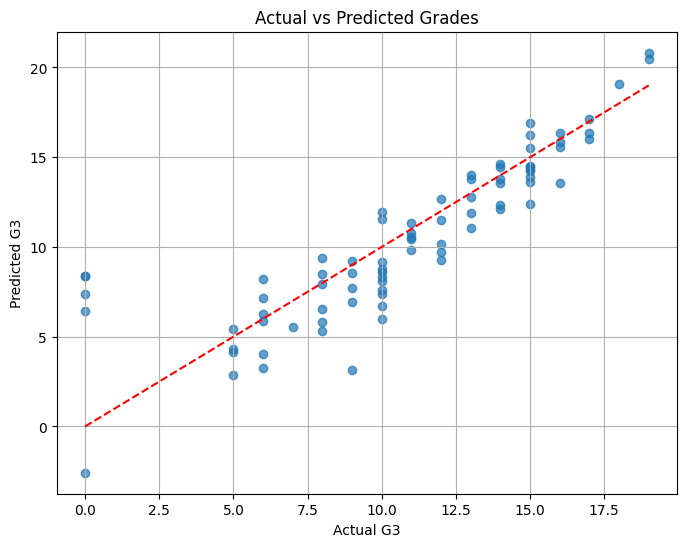

In [9]:
y_pred = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test_array, y_pred)
mse = mean_squared_error(y_test_array, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_array, y_pred)

print("Evaluation Metrics")
print("------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test_array, y_pred, alpha=0.7)
plt.plot([y_test_array.min(), y_test_array.max()], [y_test_array.min(), y_test_array.max()], "r--")
plt.title("Actual vs Predicted Grades")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.grid(True)
plt.show()

## Interpretation

The loss curves show clear convergence for all tested learning rates. A very small learning rate like `0.001` learns slowly and needs many iterations to reduce the loss, while `0.01`, `0.05`, and `0.1` converge much faster and reach almost the same final training loss.

From the evaluation output, the trained model achieved `MAE = 1.6467`, `MSE = 5.6566`, `RMSE = 2.3784`, and `R² = 0.7241`. This means the model captures the overall grade trend reasonably well, but it still has noticeable prediction error for some students, especially at the lower and upper ends of the target range.

Overall, gradient descent converged properly, and the best learning rates gave stable training with a good but not perfect level of prediction performance.